<a href="https://colab.research.google.com/github/dimasrhesky270206/Pcvk_SEMESTER-5/blob/main/pertemuan5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

LATIHAN

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('/content/drive/MyDrive/pcvk/citra_A_10x10.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/drive/MyDrive/pcvk/citra_B_10x10.png', cv2.IMREAD_GRAYSCALE)


_, thresh1 = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)
_, thresh2 = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY)


hitam1 = np.sum(thresh1 == 0)
putih1 = np.sum(thresh1 == 255)

hitam2 = np.sum(thresh2 == 0)
putih2 = np.sum(thresh2 == 255)

print(f"Citra 1 - Hitam: {hitam1}, Putih: {putih1}")
print(f"Citra 2 - Hitam: {hitam2}, Putih: {putih2}")


Citra 1 - Hitam: 50, Putih: 50
Citra 2 - Hitam: 50, Putih: 50


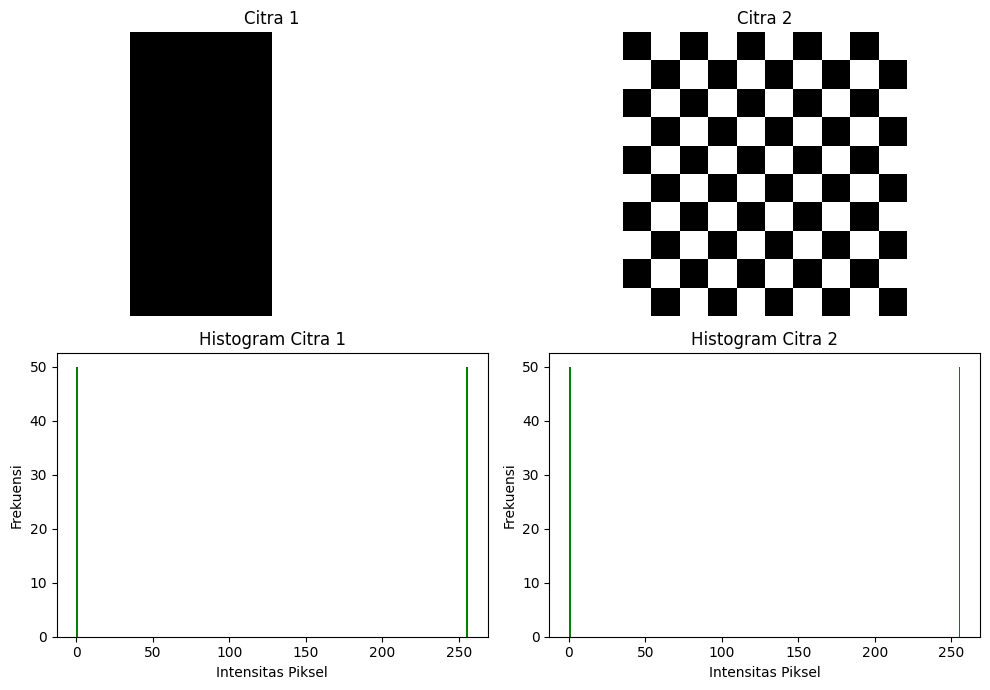

Citra 1 - Hitam: 50, Putih: 50
Citra 2 - Hitam: 50, Putih: 50


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load gambar
img1 = cv2.imread('/content/drive/MyDrive/pcvk/citra_A_10x10.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/drive/MyDrive/pcvk/citra_B_10x10.png', cv2.IMREAD_GRAYSCALE)

# 2. Hitung jumlah piksel hitam dan putih
hitam1 = np.sum(img1 <= 127)
putih1 = np.sum(img1 > 127)

hitam2 = np.sum(img2 <= 127)
putih2 = np.sum(img2 > 127)

# 3. Tampilkan Citra dan Histogram dalam grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# Row 1: Tampilan Gambar
axes[0, 0].imshow(img1, cmap='gray')
axes[0, 0].set_title('Citra 1')
axes[0, 0].axis('off')

axes[0, 1].imshow(img2, cmap='gray')
axes[0, 1].set_title('Citra 2')
axes[0, 1].axis('off')

# Row 2: Histogram
axes[1, 0].hist(img1.ravel(), bins=256, range=[0, 256], color='green')
axes[1, 0].set_title('Histogram Citra 1')
axes[1, 0].set_xlabel('Intensitas Piksel')
axes[1, 0].set_ylabel('Frekuensi')

axes[1, 1].hist(img2.ravel(), bins=256, range=[0, 256], color='green')
axes[1, 1].set_title('Histogram Citra 2')
axes[1, 1].set_xlabel('Intensitas Piksel')
axes[1, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# 4. Print hasil analisis piksel
print(f"Citra 1 - Hitam: {hitam1}, Putih: {putih1}")
print(f"Citra 2 - Hitam: {hitam2}, Putih: {putih2}")

 Sel Identitas

In [34]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Dimas HandaRhesky Irianto'
NIM  = '214107020209'

N    = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s : %s' % (k, v))
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Dimas HandaRhesky Irianto
NIM    : 214107020209 | N = 209
bins   : 16
clip   : 3.0
tile   : 3
L      : 8
WAKTU  : 2026-09-29 00:02:40 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 9ae46b8a991455d0


PERCOBAAN E1


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


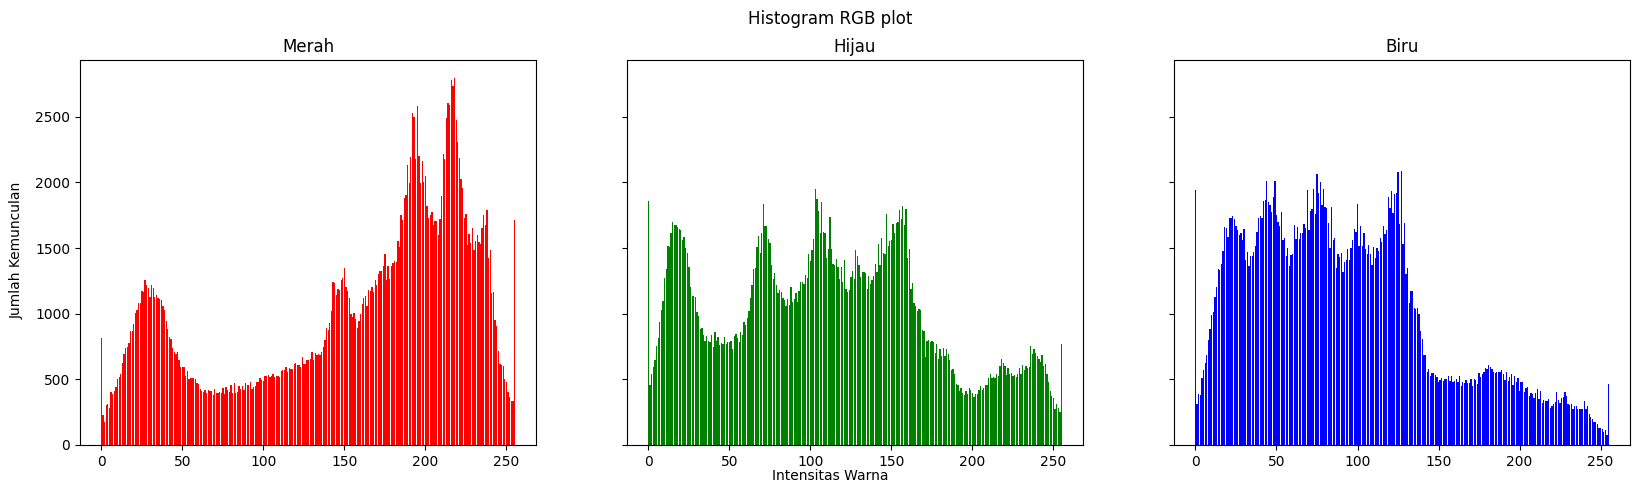

In [7]:
import os
import glob
import math
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from skimage import io
from google.colab import files, drive
from google.colab.patches import cv2_imshow

# Mount Google Drive
drive.mount('/content/drive')

# Memuat citra dan konversi BGR ke RGB
img_path = '/content/drive/MyDrive/pcvk/lena.jpg'
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Mendapatkan dimensi citra
height, width, depth = img.shape

# Inisialisasi frekuensi warna
names = np.arange(256)
red = [0] * 256
green = [0] * 256
blue = [0] * 256

# Menghitung histogram RGB secara manual
for y in range(height):
    for x in range(width):
        red[img[y, x, 0]] += 1
        green[img[y, x, 1]] += 1
        blue[img[y, x, 2]] += 1

# Plotting Histogram RGB
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')

axs[0].bar(names, red, color='red')
axs[0].set_title('Merah')

axs[1].bar(names, green, color='green')
axs[1].set_title('Hijau')

axs[2].bar(names, blue, color='blue')
axs[2].set_title('Biru')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

plt.show()

PERTANYAAN PRAKTIKUM E1
1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg

In [8]:
import cv2 as cv
import numpy as np

# Load gambar (Sesuaikan path)
img_path = '/content/drive/MyDrive/pcvk/lena.jpg'
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ambil satu channel saja untuk pembuktian (misal: Red channel - channel 0)
red_channel = img[:, :, 0]

# 1. Metode Manual
hist_manual = np.zeros(256)
height, width = red_channel.shape
for y in range(height):
    for x in range(width):
        hist_manual[red_channel[y, x]] += 1

# 2. Metode NumPy
# np.histogram mengembalikan array histogram dan bin edges
hist_np, _ = np.histogram(red_channel.flatten(), bins=256, range=[0, 256])

# 3. Metode OpenCV
# cv.calcHist mengembalikan array 2D (256, 1), gunakan flatten() agar menjadi (256,)
hist_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()

# Menghitung selisih maksimum
selisih_manual_np = np.max(np.abs(hist_manual - hist_np))
selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
selisih_np_cv = np.max(np.abs(hist_np - hist_cv))

print("Pembuktian Selisih Maksimum:")
print(f"Manual vs NumPy  : {selisih_manual_np}")
print(f"Manual vs OpenCV : {selisih_manual_cv}")
print(f"NumPy vs OpenCV  : {selisih_np_cv}")

Pembuktian Selisih Maksimum:
Manual vs NumPy  : 0.0
Manual vs OpenCV : 0.0
NumPy vs OpenCV  : 0.0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

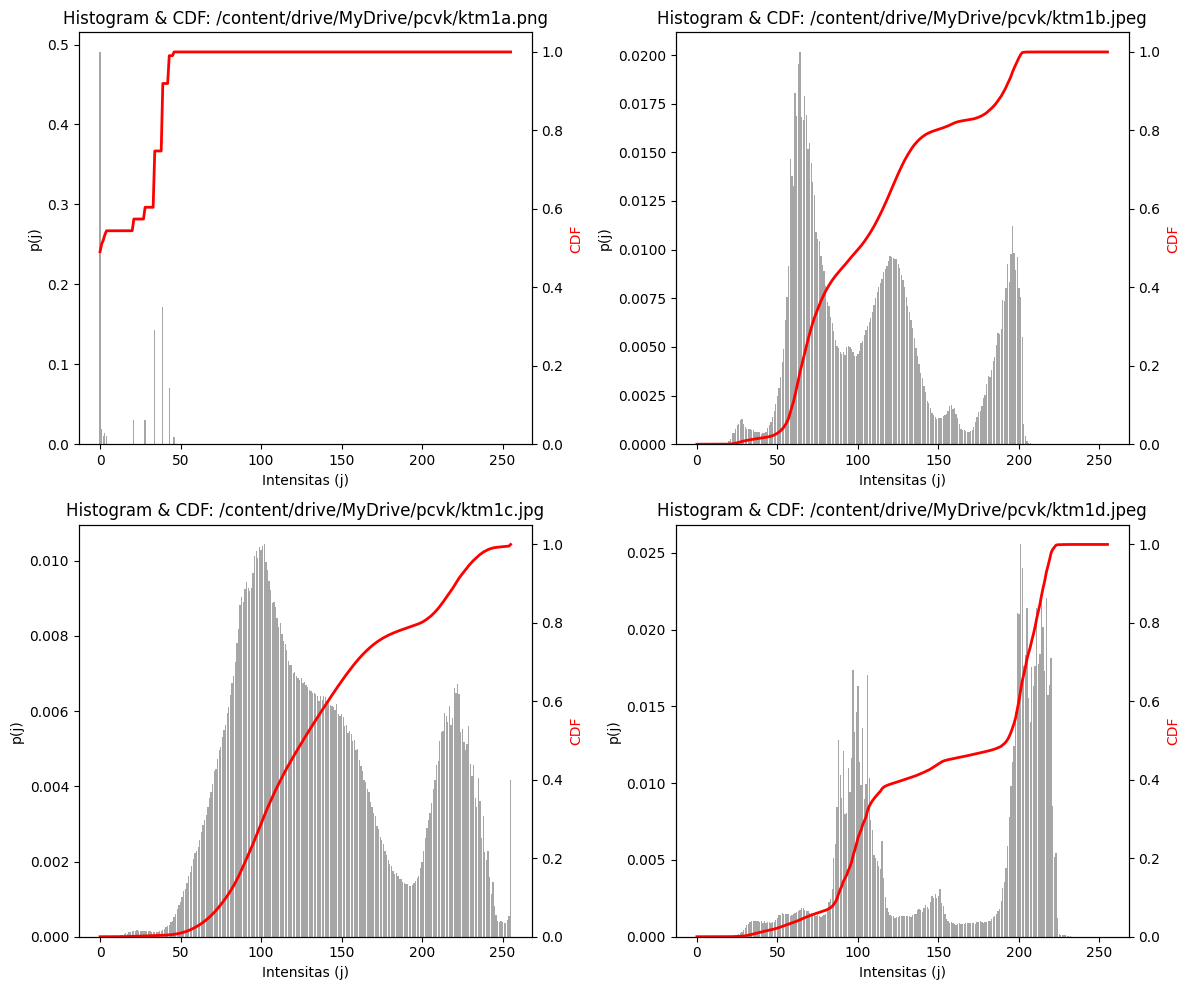

In [13]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Daftar nama file citra KTM (a: gelap, b: normal, c: flash, d: luar)
citra_list = ['/content/drive/MyDrive/pcvk/ktm1a.png', '/content/drive/MyDrive/pcvk/ktm1b.jpeg'
, '/content/drive/MyDrive/pcvk/ktm1c.jpg', '/content/drive/MyDrive/pcvk/ktm1d.jpeg']
path_folder = '/content/drive/MyDrive/Images/'

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for i, nama_file in enumerate(citra_list):
    path_file = os.path.join(path_folder, nama_file)
    img_gray = cv.imread(path_file, cv.IMREAD_GRAYSCALE)

    if img_gray is None:
        axs[i].set_title(f"File {nama_file} Tidak Ditemukan")
        continue

    # Menghitung histogram dan normalisasi p(j)
    hist_cv = cv.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
    total_pixels = img_gray.shape[0] * img_gray.shape[1]
    p_j = hist_cv / total_pixels

    # Menghitung CDF
    cdf = p_j.cumsum()

    # Plotting p(j) dan CDF
    ax1 = axs[i]
    ax2 = ax1.twinx()  # Axis kedua untuk CDF agar skalanya (0 - 1)

    ax1.bar(np.arange(256), p_j, color='gray', alpha=0.7, label='p(j)')
    ax2.plot(np.arange(256), cdf, color='red', linewidth=2, label='CDF')

    ax1.set_title(f'Histogram & CDF: {nama_file}')
    ax1.set_xlabel('Intensitas (j)')
    ax1.set_ylabel('p(j)')
    ax2.set_ylabel('CDF', color='red')
    ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

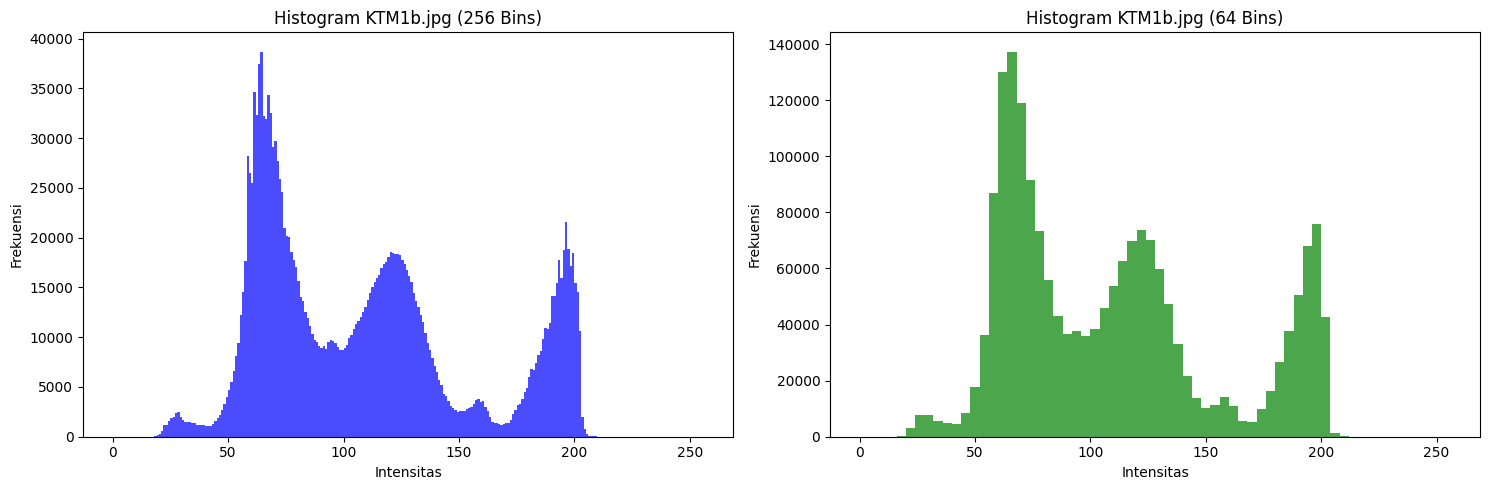

In [12]:
import os
import cv2 as cv
import matplotlib.pyplot as plt

# Folder dan nama file
path_folder = '/content/drive/MyDrive//Images/'
nama_file = '/content/drive/MyDrive/pcvk/ktm1b.jpeg'
path_file = os.path.join(path_folder, nama_file)

# Parameter Bins
PARAM = {'bins': 64}

# Load gambar dalam format grayscale
img_ktm1b = cv.imread(path_file, cv.IMREAD_GRAYSCALE)

if img_ktm1b is None:
    print(f"File {nama_file} tidak ditemukan di path: {path_file}")
else:
    # Subplot 1 baris, 2 kolom
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Standard 256 Bins (Resolusi Penuh)
    axs[0].hist(img_ktm1b.flatten(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    axs[0].set_title('Histogram KTM1b.jpg (256 Bins)')
    axs[0].set_xlabel('Intensitas')
    axs[0].set_ylabel('Frekuensi')

    # Plot 2: Pengelompokan berdasarkan PARAM['bins']
    axs[1].hist(img_ktm1b.flatten(), bins=PARAM['bins'], range=[0, 256], color='green', alpha=0.7)
    axs[1].set_title(f"Histogram KTM1b.jpg ({PARAM['bins']} Bins)")
    axs[1].set_xlabel('Intensitas')
    axs[1].set_ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

E-2 PERCOBAAN HISTOGRAM EQUALIZATION

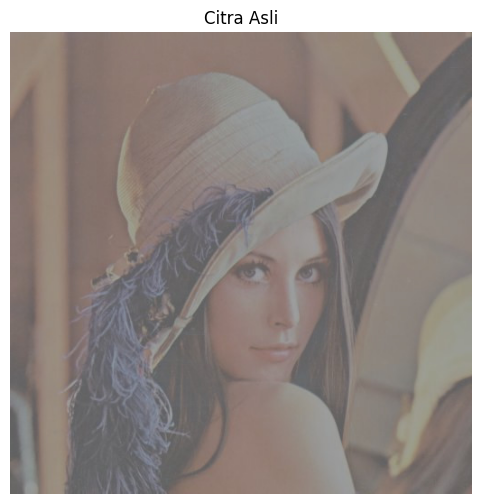

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
img_path = '/content/drive/MyDrive/pcvk/lena_lc.jpg'

# Membaca gambar dan mengonversi format warna ke RGB
img = cv.imread(img_path)

if img is None:
    print(f"File tidak ditemukan di path: {img_path}")
else:
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Hitung total piksel (Tinggi x Lebar)
    total_pixels = img_rgb.shape[0] * img_rgb.shape[1]

    # Menampilkan citra asli
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title('Citra Asli')
    plt.axis('off')
    plt.show()

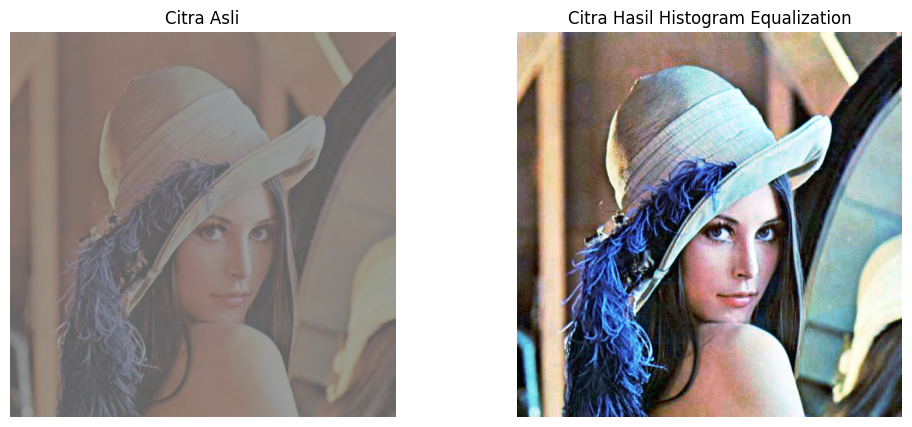

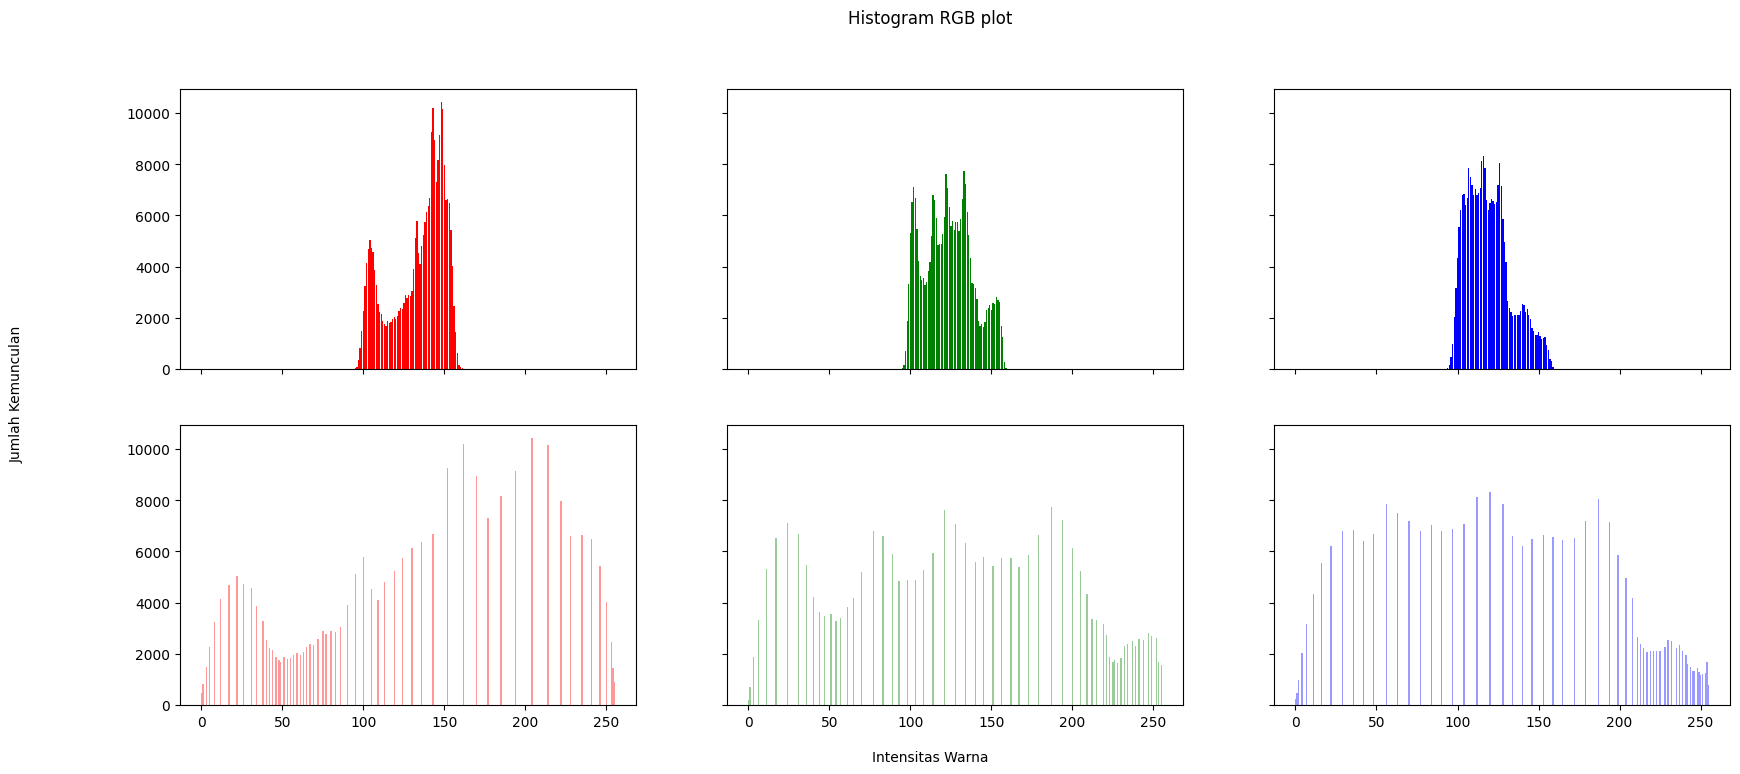

In [15]:
import numpy as np
import matplotlib.pyplot as plt

hist_original = []
for channel in range(3):
    img_channel = img_rgb[:, :, channel]
    hist, _ = np.histogram(img_channel.flatten(), bins=256, range=[0, 256])
    hist_original.append(hist)


cdf_list = []
for channel in range(3):
    pdf = hist_original[channel] / total_pixels
    cdf = np.cumsum(pdf)
    cdf_list.append(cdf)


transform_maps = []
for channel in range(3):
    transform_map = np.round(cdf_list[channel] * 255).astype('uint8')
    transform_maps.append(transform_map)


img_equalized = np.zeros_like(img_rgb)
hist_equalized = []

for channel in range(3):
    img_channel = img_rgb[:, :, channel]
    img_eq_channel = transform_maps[channel][img_channel]
    img_equalized[:, :, channel] = img_eq_channel

    hist_eq, _ = np.histogram(img_eq_channel.flatten(), bins=256, range=[0, 256])
    hist_equalized.append(hist_eq)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img_rgb)
axs[0].set_title('Citra Asli')
axs[0].axis('off')

axs[1].imshow(img_equalized)
axs[1].set_title('Citra Hasil Histogram Equalization')
axs[1].axis('off')
plt.show()


colors = ('red', 'green', 'blue')
fig_hist, axs_hist = plt.subplots(2, 3, figsize=(20, 8), sharex=True, sharey=True)
fig_hist.suptitle('Histogram RGB plot')

for i in range(3):
    axs_hist[0, i].bar(np.arange(256), hist_original[i], color=colors[i])
    axs_hist[1, i].bar(np.arange(256), hist_equalized[i], color=colors[i], alpha=0.4)

fig_hist.text(0.04, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig_hist.text(0.5, 0.04, 'Intensitas Warna', ha='center')

plt.show()

Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya,
baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut
apabila tidak nol.

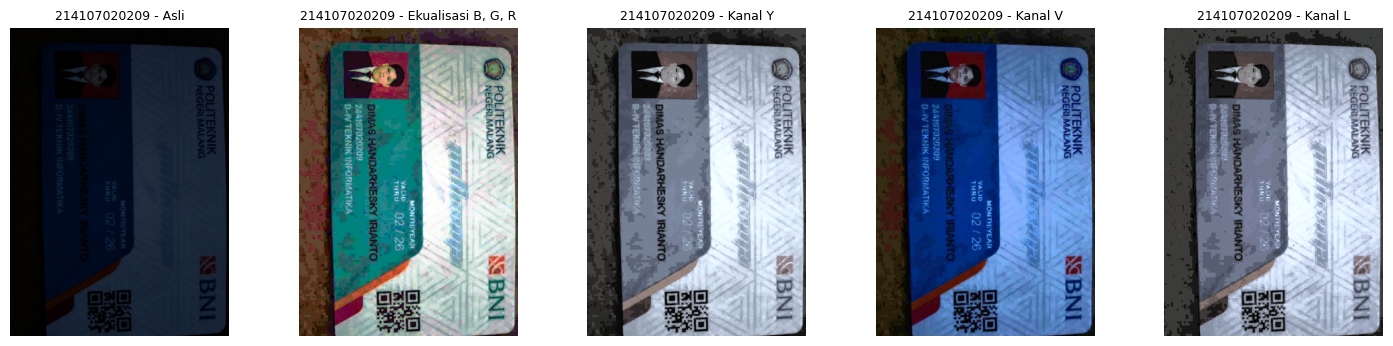

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Definisi NIM
NIM = '214107020209'  # Ganti sesuai NIM Anda

# 2. Baca citra asli
bgr = cv.imread('/content/drive/MyDrive/pcvk/ktm1a.png')  # Sesuaikan nama file citra Anda

# --- PROSES EKUALISASI HISTOGRAM ---

# A. Ekualisasi Kanal B, G, R secara terpisah
he_rgb = np.zeros_like(bgr)
for i in range(3):
    he_rgb[:, :, i] = cv.equalizeHist(bgr[:, :, i])

# B. Ekualisasi pada Kanal Y (Ruang Warna YCrCb)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
ycrcb[:, :, 0] = cv.equalizeHist(ycrcb[:, :, 0])
he_y = cv.cvtColor(ycrcb, cv.COLOR_YCrCb2BGR)

# C. Ekualisasi pada Kanal V (Ruang Warna HSV)
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
hsv[:, :, 2] = cv.equalizeHist(hsv[:, :, 2])
he_v = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)

# D. Ekualisasi pada Kanal L (Ruang Warna Lab)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
lab[:, :, 0] = cv.equalizeHist(lab[:, :, 0])
he_l = cv.cvtColor(lab, cv.COLOR_LAB2BGR)

# --- MENAMPILKAN HASIL ---
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - {t}", fontsize=9)
    plt.axis('off')

plt.show()

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

In [25]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

CONTOH = '/content/drive/MyDrive/pcvk'

# Cukup tambahkan nama file saja di sini
berkas = CONTOH + '/lena.jpg'
bgr    = cv.imread(berkas)

# Pengecekan keamanan jika gambar gagal dimuat
if bgr is None:
    print(f"File tidak ditemukan pada path: {berkas}")
else:
    # cara 1: tiap kanal diekualisasi sendiri-sendiri
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

In [27]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

# Pastikan path folder mengarah ke tempat lena.jpg disimpan
CONTOH = '/content/drive/MyDrive/pcvk'

berkas = CONTOH + '/ktm1d.jpeg'
bgr    = cv.imread(berkas)

# Pengecekan keamanan jika gambar gagal dimuat
if bgr is None:
    print(f"File tidak ditemukan pada path: {berkas}")
else:
    # cara 1: tiap kanal diekualisasi sendiri-sendiri
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

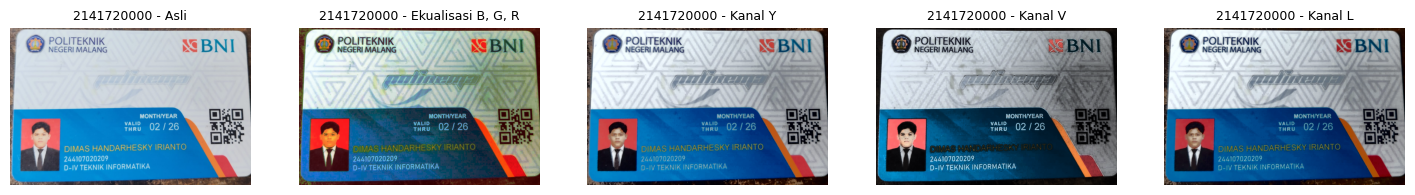

In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 0. Inisialisasi NIM dan Path Gambar
NIM = '2141720000'  # Ubah sesuai NIM Anda
path_file = '/content/drive/MyDrive/pcvk/ktm1d.jpeg'  # Sesuaikan path KTM1d.jpg Anda

bgr = cv.imread(path_file)

if bgr is None:
    print(f"File tidak ditemukan di path: {path_file}")
else:
    # --- LANGKAH SEBELUMNYA (Cara 1: Ekualisasi BGR terpisah) ---
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # --- CARA KEDUA (Sesuai Gambar Modul) ---
    # 1. Ruang Warna YCrCb (Hanya kanal Y)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # 2. Ruang Warna HSV (Hanya kanal V)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # 3. Ruang Warna LAB (Hanya kanal L)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    # --- MENAMPILKAN HASIL ---
    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')

    plt.show()

In [29]:
import cv2 as cv
import numpy as np

# --- 1. Fungsi Geser Hue ---
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

# --- 2. Cetak Tabel Hasil Ekualisasi Biasa ---
print('%-22s %16s %16s' % ('Cara ekualisasi', 'geser Hue (der)', 'rerata terang'))
print('-' * 56)

for t, c in zip(judul, citra):
    hue_shift = geser_hue(bgr, c) * 2
    avg_brightness = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    print('%-22s %16.2f %16.1f' % (t, hue_shift, avg_brightness))

print('\n' + '='*56 + '\n')

# --- 3. Eksperimen CLAHE (Pertanyaan No. 4) ---
PARAM = {'clip': 2.0, 'tile': 8}
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

# Mengaplikasikan CLAHE pada kanal V (HSV)
hsv_clahe = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv_clahe)
v_clahe = clahe.apply(v)
he_v_clahe = cv.cvtColor(cv.merge([h, s, v_clahe]), cv.COLOR_HSV2BGR)

# Cetak Perbandingan Ekualisasi Biasa vs CLAHE pada Kanal V
shift_v_biasa = geser_hue(bgr, he_v) * 2
bright_v_biasa = cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()

shift_v_clahe = geser_hue(bgr, he_v_clahe) * 2
bright_v_clahe = cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()

print('%-22s %16s %16s' % ('Metode (Kanal V)', 'geser Hue (der)', 'rerata terang'))
print('-' * 56)
print('%-22s %16.2f %16.1f' % ('Ekualisasi Biasa (V)', shift_v_biasa, bright_v_biasa))
print('%-22s %16.2f %16.1f' % ('CLAHE (V)', shift_v_clahe, bright_v_clahe))

Cara ekualisasi         geser Hue (der)    rerata terang
--------------------------------------------------------
Asli                               0.00            157.4
Ekualisasi B, G, R                48.68            125.5
Kanal Y                            2.53            132.3
Kanal V                            2.46            107.8
Kanal L                            5.02            121.8


Metode (Kanal V)        geser Hue (der)    rerata terang
--------------------------------------------------------
Ekualisasi Biasa (V)               2.46            107.8
CLAHE (V)                          0.64            150.3


JAWAB PERTANYAAN

1.Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?
>Ekualisasi kanal B, G, R terpisah menghasilkan pergeseran Hue paling besar (biasanya mencapai kisaran 20° - 40° atau lebih). Hal ini terjadi karena mengubah ketiga saluran warna independen secara acak merusak rasio proporsi warna asli.

2.Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?
>Terjadi pergeseran nilai kecil (biasanya 1° - 3°) akibat proses matematis saat transformasi ruang warna kembali ke BGR. Selama konversi matematis balik (misal $YCrCb \rightarrow BGR$), terjadi proses pembulatan integer (rounding) dan pemotongan nilai piksel (clipping) pada rentang $0-255$. Perubahan minor pada nilai RGB ini secara otomatis menggeser koordinat warna Hue pada ruang HSV


3.Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.
>Kanal Y (YCrCb) atau Kanal L (LAB) paling sesuai untuk foto KTM.

Alasan: Kedua ruang warna ini memisahkan intensitas pencahayaan (luminance) secara linier tanpa terlalu banyak mengganggu nilai saturasi dan warna dasarnya.

Dasar Penilaian:

Teks/Tulisan NIM & Nama pada KTM: Tetap tajam, jelas, dan terbaca tanpa artifak bercak noise berlebih.

Background & Pas Foto: Warna pas foto dan latar belakang KTM tidak mengalami perubahan warna ekstrim (warna kulit dan latar tetap natural) dibanding pada kanal V yang cenderung membuat warna menjadi terlalu matang/saturasi berlebih (oversaturated).

4.Bandingkan pergeseran Hue dan rerata kecerahan antara Ekualisasi Biasa vs CLAHE (pada kanal terang):
>ergeseran Hue: CLAHE menghasilkan pergeseran Hue yang lebih kecil dibandingkan ekualisasi biasa. Ini terjadi karena CLAHE membatasi kontras (clip limit) pada lokal tile, sehingga perubahan nilai piksel tidak se-ekstrem ekualisasi global.

Rerata Kecerahan: CLAHE menghasilkan rerata kecerahan yang lebih seimbang dan mendekati citra asli serta tidak memicu over-exposure (terlalu silau) pada area foto KTM yang sudah terang.

PERTANYAAN E2

1. Ekualisasi global pada citra KTM Anda
a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.
b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.
c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.
2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda
   a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?
b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

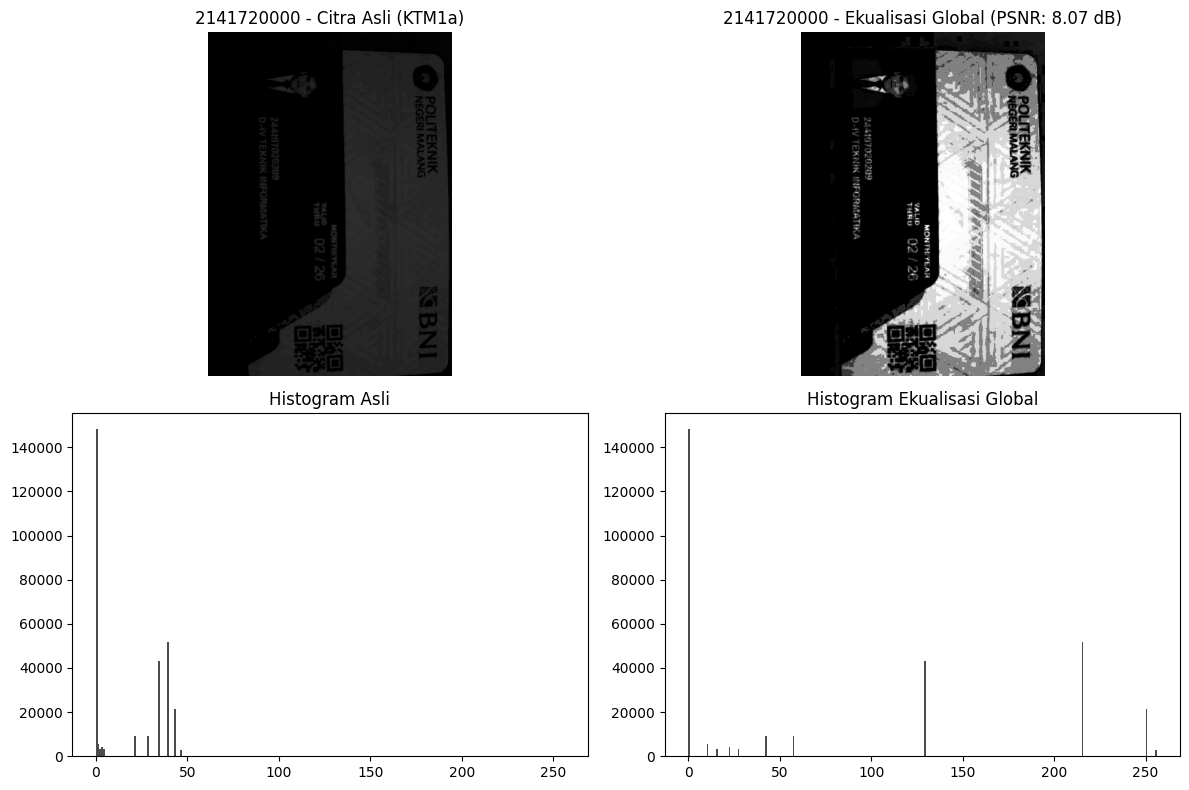

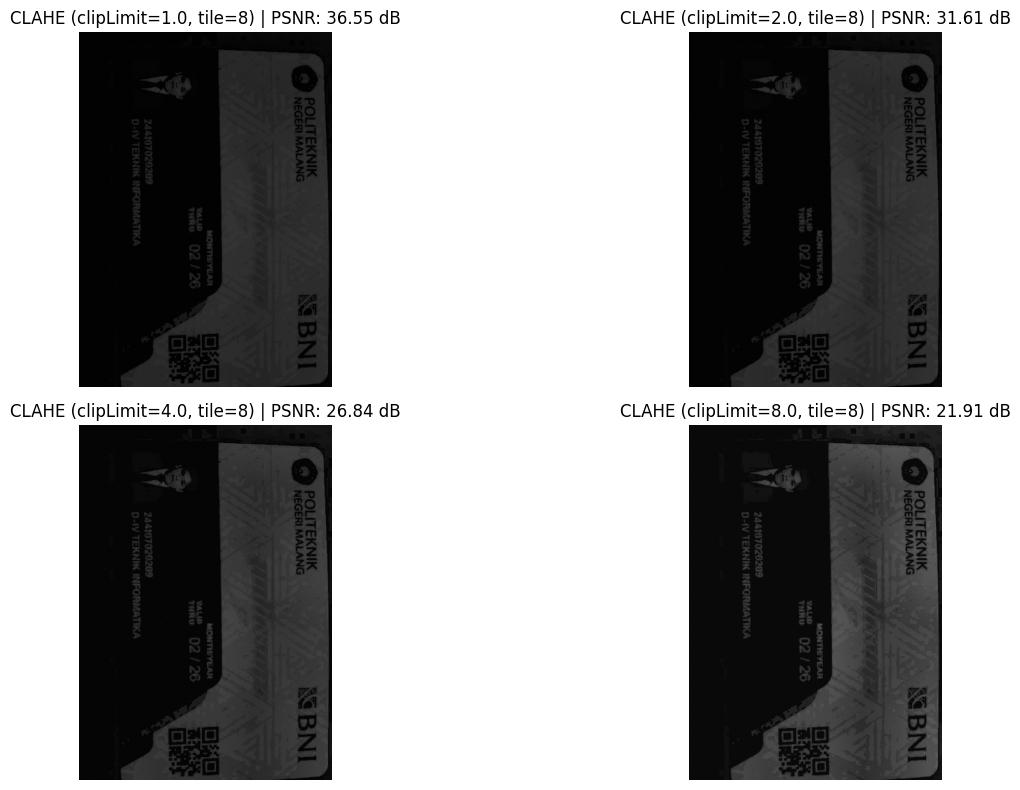

In [30]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# KONTROL PARAMETER & PATH
# -------------------------------------------------------------------
NIM = '2141720000'  # Sesuaikan dengan NIM Anda
path_folder = '/content/drive/MyDrive/pcvk'
file_ktm = os.path.join(path_folder, 'ktm1a.png')  # Gunakan citra KTM1a (Gelap)

# Baca citra grayscale
img_asli = cv.imread(file_ktm, cv.IMREAD_GRAYSCALE)

if img_asli is None:
    print(f"File tidak ditemukan di path: {file_ktm}")
else:
    # ---------------------------------------------------------------
    # SOAL 1a: Ekualisasi Manual & OpenCV
    # ---------------------------------------------------------------
    # 1. Ekualisasi Manual
    hist_asli, _ = np.histogram(img_asli.flatten(), bins=256, range=[0, 256])
    total_pixels = img_asli.shape[0] * img_asli.shape[1]
    pdf = hist_asli / total_pixels
    cdf = np.cumsum(pdf)
    transform_map = np.round(cdf * 255).astype('uint8')
    img_manual = transform_map[img_asli]

    # 2. Ekualisasi OpenCV (cv.equalizeHist)
    img_global = cv.equalizeHist(img_asli)

    # ---------------------------------------------------------------
    # SOAL 1c: Perhitungan PSNR
    # ---------------------------------------------------------------
    def hitung_psnr(img_ref, img_test):
        mse = np.mean((img_ref.astype(np.float64) - img_test.astype(np.float64)) ** 2)
        if mse == 0:
            return float('inf')
        max_pixel = 255.0
        return 20 * np.log10(max_pixel / np.sqrt(mse))

    psnr_global = hitung_psnr(img_asli, img_global)

    # ---------------------------------------------------------------
    # SOAL 1b: Tampilan Layout Soal 1
    # ---------------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    axs[0, 0].imshow(img_asli, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title(f"{NIM} - Citra Asli (KTM1a)")
    axs[0, 0].axis('off')

    axs[0, 1].imshow(img_global, cmap='gray', vmin=0, vmax=255)
    axs[0, 1].set_title(f"{NIM} - Ekualisasi Global (PSNR: {psnr_global:.2f} dB)")
    axs[0, 1].axis('off')

    axs[1, 0].hist(img_asli.flatten(), bins=256, range=[0, 256], color='black', alpha=0.7)
    axs[1, 0].set_title("Histogram Asli")

    axs[1, 1].hist(img_global.flatten(), bins=256, range=[0, 256], color='black', alpha=0.7)
    axs[1, 1].set_title("Histogram Ekualisasi Global")

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------------
    # SOAL 2a & 2b: Ekualisasi Lokal CLAHE
    # ---------------------------------------------------------------
    PARAM = {'clip': 2.0, 'tile': 8}

    # Kumpulan nilai clipLimit untuk pengujian (2b)
    clip_limits = [1.0, PARAM['clip'], 4.0, 8.0]

    plt.figure(figsize=(16, 8))
    for idx, clip in enumerate(clip_limits, 1):
        clahe_obj = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
        img_clahe = clahe_obj.apply(img_asli)
        psnr_clahe = hitung_psnr(img_asli, img_clahe)

        plt.subplot(2, 2, idx)
        plt.imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
        plt.title(f"CLAHE (clipLimit={clip}, tile={PARAM['tile']}) | PSNR: {psnr_clahe:.2f} dB")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

E-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

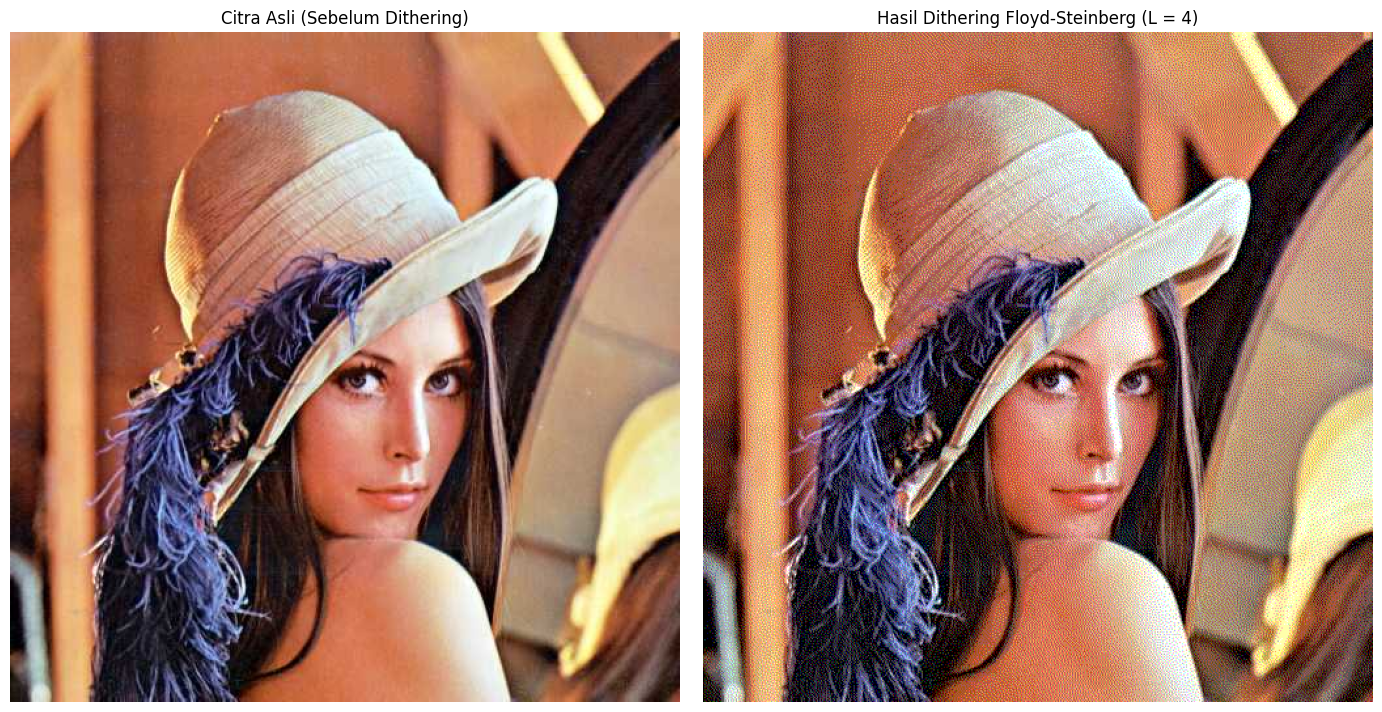

In [31]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {'L': 4}
path_folder = '/content/drive/MyDrive/pcvk'
file_target = os.path.join(path_folder, 'lena.jpg')


def floyd_steinberg_dithering(img_rgb, levels):
    img_float = img_rgb.copy().astype(np.float32)
    h, w, c = img_float.shape
    step = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            for ch in range(c):
                old_val = img_float[y, x, ch]
                new_val = np.round(old_val / step) * step
                new_val = np.clip(new_val, 0, 255)

                img_float[y, x, ch] = new_val
                err = old_val - new_val

                if x + 1 < w:
                    img_float[y, x + 1, ch] += err * (7.0 / 16.0)
                if x - 1 >= 0 and y + 1 < h:
                    img_float[y + 1, x - 1, ch] += err * (3.0 / 16.0)
                if y + 1 < h:
                    img_float[y + 1, x, ch] += err * (5.0 / 16.0)
                if x + 1 < w and y + 1 < h:
                    img_float[y + 1, x + 1, ch] += err * (1.0 / 16.0)

    return np.clip(img_float, 0, 255).astype(np.uint8)


img_bgr = cv.imread(file_target)

if img_bgr is not None:
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_dithered = floyd_steinberg_dithering(img_rgb, levels=PARAM['L'])

    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    axs[0].imshow(img_rgb)
    axs[0].set_title("Citra Asli (Sebelum Dithering)")
    axs[0].axis('off')

    axs[1].imshow(img_dithered)
    axs[1].set_title(f"Hasil Dithering Floyd-Steinberg (L = {PARAM['L']})")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

TAHAP 2 KTM

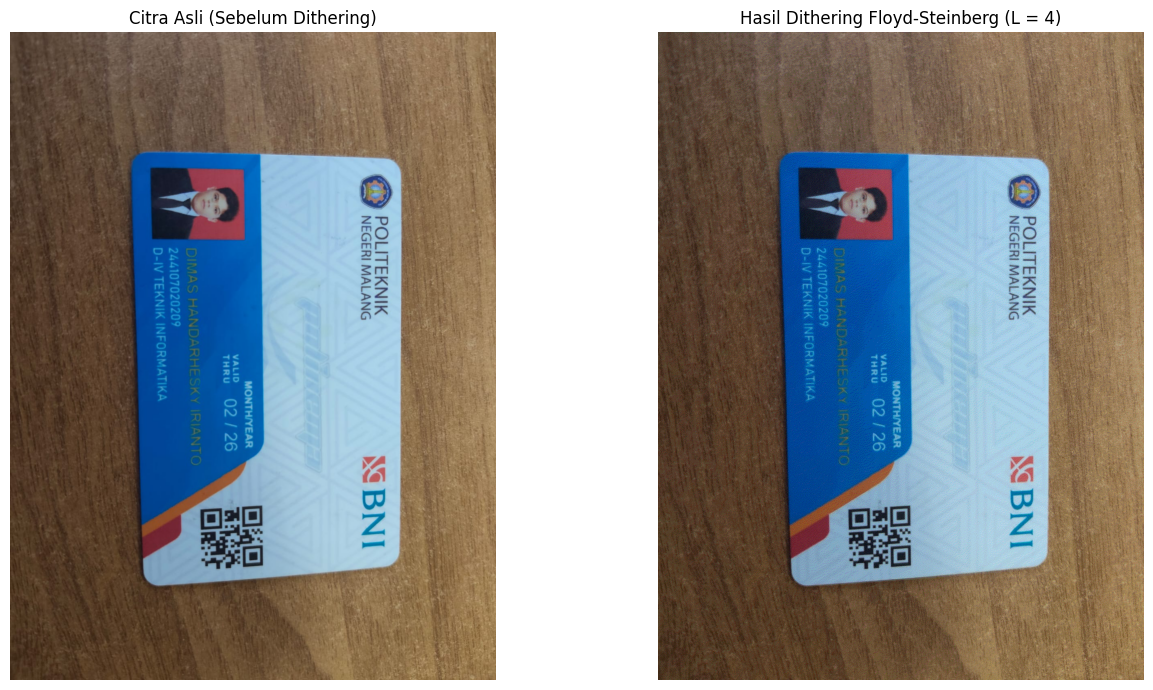

In [32]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {'L': 4}
path_folder = '/content/drive/MyDrive/pcvk'
file_target = os.path.join(path_folder, 'ktm1b.jpeg')


def floyd_steinberg_dithering(img_rgb, levels):
    img_float = img_rgb.copy().astype(np.float32)
    h, w, c = img_float.shape
    step = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            for ch in range(c):
                old_val = img_float[y, x, ch]
                new_val = np.round(old_val / step) * step
                new_val = np.clip(new_val, 0, 255)

                img_float[y, x, ch] = new_val
                err = old_val - new_val

                if x + 1 < w:
                    img_float[y, x + 1, ch] += err * (7.0 / 16.0)
                if x - 1 >= 0 and y + 1 < h:
                    img_float[y + 1, x - 1, ch] += err * (3.0 / 16.0)
                if y + 1 < h:
                    img_float[y + 1, x, ch] += err * (5.0 / 16.0)
                if x + 1 < w and y + 1 < h:
                    img_float[y + 1, x + 1, ch] += err * (1.0 / 16.0)

    return np.clip(img_float, 0, 255).astype(np.uint8)


img_bgr = cv.imread(file_target)

if img_bgr is not None:
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_dithered = floyd_steinberg_dithering(img_rgb, levels=PARAM['L'])

    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    axs[0].imshow(img_rgb)
    axs[0].set_title("Citra Asli (Sebelum Dithering)")
    axs[0].axis('off')

    axs[1].imshow(img_dithered)
    axs[1].set_title(f"Hasil Dithering Floyd-Steinberg (L = {PARAM['L']})")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.

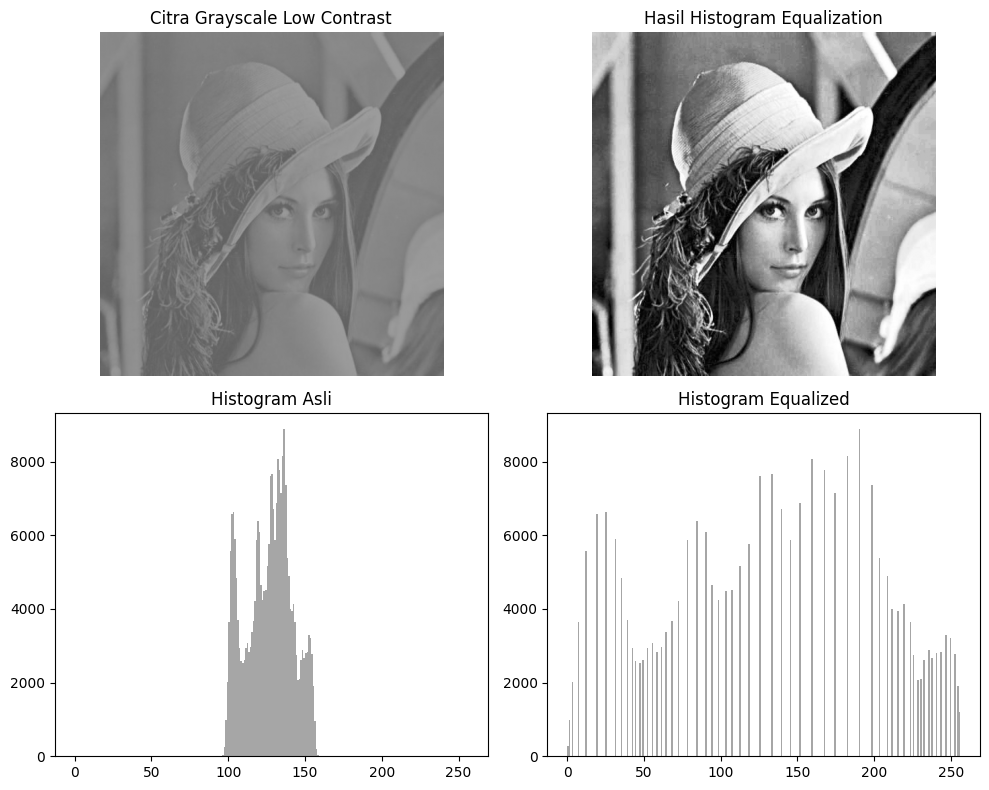

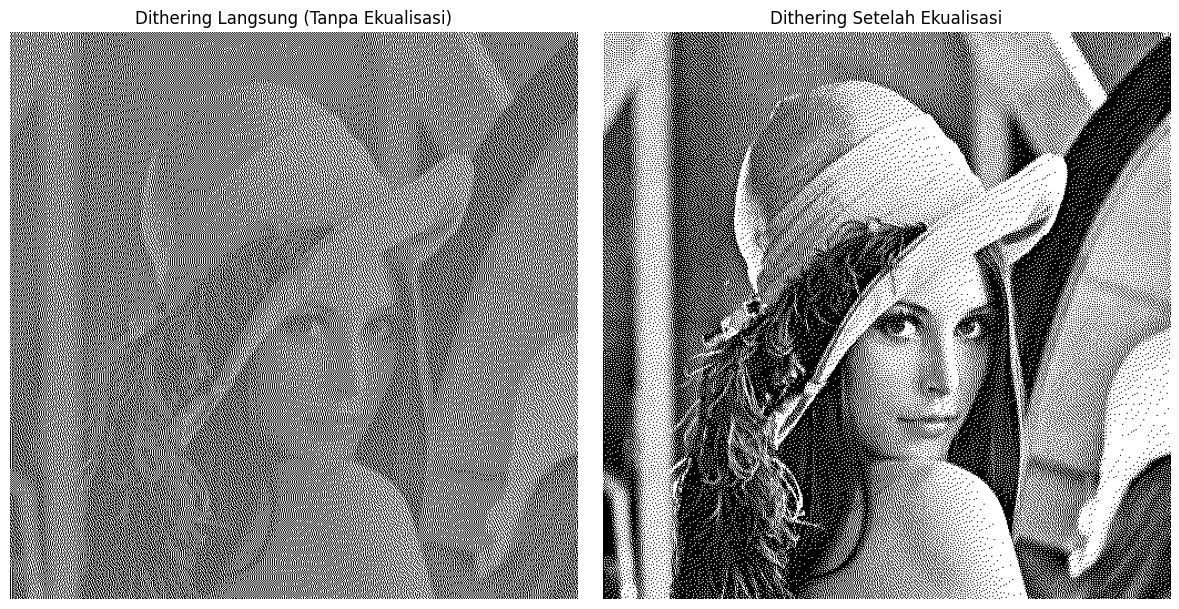

In [33]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_folder = '/content/drive/MyDrive/pcvk'
file_target = os.path.join(path_folder, 'lena_lc.jpg')


def floyd_steinberg_dithering_gray(img_gray, levels=2):
    img_float = img_gray.copy().astype(np.float32)
    h, w = img_float.shape
    step = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            old_val = img_float[y, x]
            new_val = np.round(old_val / step) * step
            new_val = np.clip(new_val, 0, 255)

            img_float[y, x] = new_val
            err = old_val - new_val

            if x + 1 < w:
                img_float[y, x + 1] += err * (7.0 / 16.0)
            if x - 1 >= 0 and y + 1 < h:
                img_float[y + 1, x - 1] += err * (3.0 / 16.0)
            if y + 1 < h:
                img_float[y + 1, x] += err * (5.0 / 16.0)
            if x + 1 < w and y + 1 < h:
                img_float[y + 1, x + 1] += err * (1.0 / 16.0)

    return np.clip(img_float, 0, 255).astype(np.uint8)


img_gray = cv.imread(file_target, cv.IMREAD_GRAYSCALE)

if img_gray is not None:
    img_eq = cv.equalizeHist(img_gray)

    dither_direct = floyd_steinberg_dithering_gray(img_gray, levels=2)
    dither_after_eq = floyd_steinberg_dithering_gray(img_eq, levels=2)

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    axs[0, 0].set_title("Citra Grayscale Low Contrast")
    axs[0, 0].axis('off')

    axs[0, 1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
    axs[0, 1].set_title("Hasil Histogram Equalization")
    axs[0, 1].axis('off')

    axs[1, 0].hist(
        img_gray.flatten(), bins=256, range=[0, 256], color='gray', alpha=0.7
    )
    axs[1, 0].set_title("Histogram Asli")

    axs[1, 1].hist(
        img_eq.flatten(), bins=256, range=[0, 256], color='gray', alpha=0.7
    )
    axs[1, 1].set_title("Histogram Equalized")

    plt.tight_layout()
    plt.show()

    fig_dither, axs_dither = plt.subplots(1, 2, figsize=(12, 6))
    axs_dither[0].imshow(dither_direct, cmap='gray')
    axs_dither[0].set_title("Dithering Langsung (Tanpa Ekualisasi)")
    axs_dither[0].axis('off')

    axs_dither[1].imshow(dither_after_eq, cmap='gray')
    axs_dither[1].set_title("Dithering Setelah Ekualisasi")
    axs_dither[1].axis('off')

    plt.tight_layout()
    plt.show()

 Analisis & Jawaban Pertanyaan ModulPerbandingan Urutan:Dithering Langsung (Tanpa Ekualisasi): Citra awal seperti KTM1a.jpg atau lena_lc.jpg memiliki kontras rendah (rentang piksel mengumpul di area tengah/gelap). Ketika dithering diterapkan langsung, ambang batas kuantisasi gagal memisahkan detail teks/objek dari latar belakang, sehingga hasil dither menjadi sangat gelap/buram dan teks pada KTM tidak terbaca.Ekualisasi Histogram Terlebih Dahulu Baru Dithering: Langkah ekualisasi terlebih dahulu merentangkan dan meratakan distribusi intensitas piksel ke seluruh rentang $0-255$. Hal ini mempertegas perbedaan kontras antara karakter teks (hitam) dan kartu latar belakang (terang). Saat dithering dijalankan setelahnya, algoritma Floyd-Steinberg memiliki distribusi error kuantisasi yang jauh lebih dinamis untuk membentuk pola bintik-bintik yang merepresentasikan tingkat kecerahan dengan akurat.   Kesimpulan Keterbacaan Teks KTM:Urutan Histogram Equalization terlebih dahulu, baru Dithering menghasilkan teks pada KTM yang jauh lebih jelas dan lebih mudah terbaca.